In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LinearRegression

In [2]:
# 2.2 Data Description and Exploratory Data Analysis
# Data Import
data= pd.read_csv("dirty_cafe_sales.csv",header=0,sep=",")
# Data size
print("Top 5 Rows: \n",data.head())
print('\n Dataset shape: ',data.shape)
print("\n Number of columns: ",data.shape[1])
print("\n Number of rows: ",data.shape[0])

Top 5 Rows: 
   Transaction ID    Item Quantity Price Per Unit Total Spent  Payment Method  \
0    TXN_1961373  Coffee        2            2.0         4.0     Credit Card   
1    TXN_4977031    Cake        4            3.0        12.0            Cash   
2    TXN_4271903  Cookie        4            1.0       ERROR     Credit Card   
3    TXN_7034554   Salad        2            5.0        10.0         UNKNOWN   
4    TXN_3160411  Coffee        2            2.0         4.0  Digital Wallet   

   Location Transaction Date  
0  Takeaway       2023-09-08  
1  In-store       2023-05-16  
2  In-store       2023-07-19  
3   UNKNOWN       2023-04-27  
4  In-store       2023-06-11  

 Dataset shape:  (10000, 8)

 Number of columns:  8

 Number of rows:  10000


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB
None
Summary statistics: n\            Quantity  Price Per Unit  Total Spent            Transaction Date
count  9942.000000     9942.000000  9942.000000                        9485
mean      3.025749        2.947848     8.931855  2023-07-01 23:58:10.690564
min       1.000000        1.000000     1.000000         2023-01-01 00:00:00
25%       2.000000        2.000000     4.000000         2023-04-01 00:00:00
50%    

<>:39: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:39: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_6300\1250586313.py:39: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
  print("Summary statistics: n\ ", data.describe())


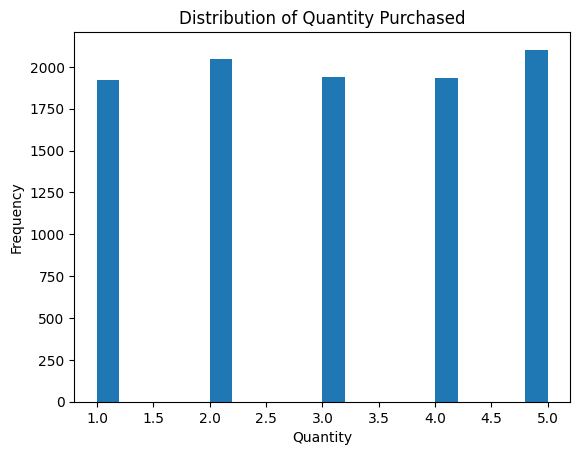

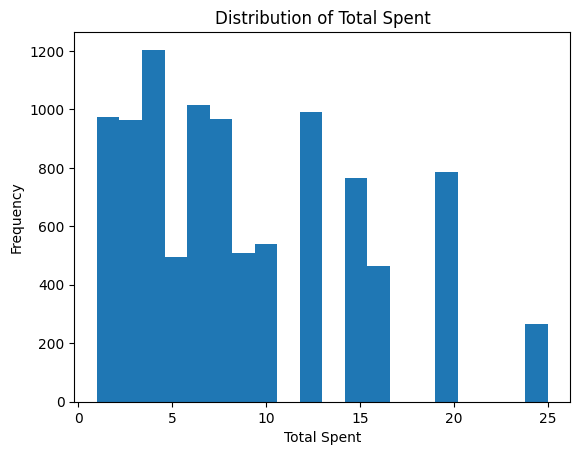

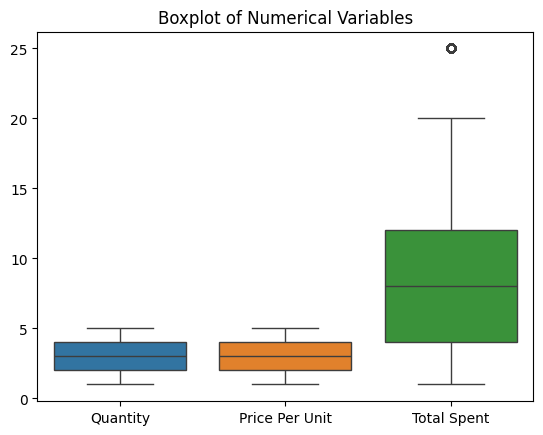

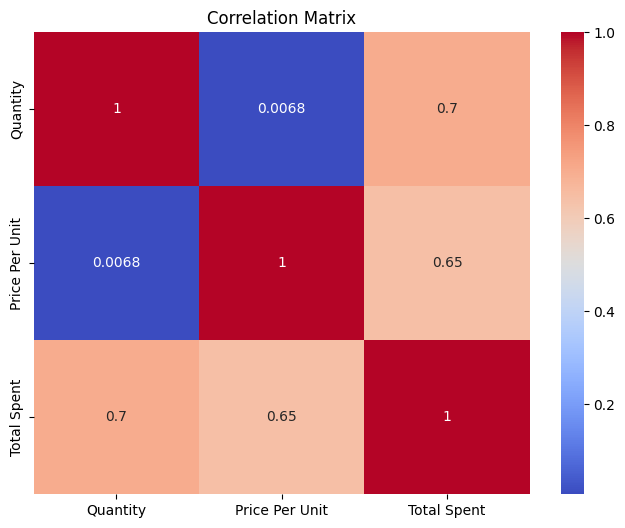

In [3]:
# Description of virables
print(data.info())
# Converting numerical columns to numerical values
data["Quantity"] = pd.to_numeric(data["Quantity"],errors = "coerce")
data["Price Per Unit"] = pd.to_numeric(data["Price Per Unit"],errors = "coerce")
data["Total Spent"] = pd.to_numeric(data["Total Spent"],errors = "coerce")
# Convert transaction date to date
data["Transaction Date"] = pd.to_datetime(data["Transaction Date"],errors = "coerce")

# Handling missing numerical values
#If Quantity and Price Per Unit exist
data.loc[
    data["Total Spent"].isna() &
    data["Quantity"].notna() &
    data["Price Per Unit"].notna(), "Total Spent"
] = data["Quantity"] * data["Price Per Unit"]
#If Total Spent and Quantity exist
data.loc[
    data["Price Per Unit"].isna() &
    data["Total Spent"].notna() &
    data["Quantity"].notna(), "Price Per Unit"
] = data["Total Spent"] / data["Quantity"]
# If Total Spent and Price Per Unit exist
data.loc[
    data["Quantity"].isna() &
    data["Total Spent"].notna() &
    data["Price Per Unit"].notna(), "Quantity"
] = data["Total Spent"] / data["Price Per Unit"]

#Deleting rows we can't recover
data.dropna(subset=["Quantity", "Price Per Unit", "Total Spent"], inplace=True)
#The variables Quantity, Price Per Unit, and Total Spent demonstrate 
#relationship where Total Spent equals the product of Quantity and Price Per Unit. 
#This relationship was used to reconstruct missing values. If two of the three 
#variables were present, the third was calculated using the known formula. Rows where 
#insufficient information was available to recover missing values were removed from the dataset.

#Summary Statistics
print("Summary statistics: n\ ", data.describe())

# Visualizations
# Histogram for Quantity
plt.hist(data["Quantity"], bins = 20)
plt.title("Distribution of Quantity Purchased")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()
#Histogram for Total Spent
plt.hist(data["Total Spent"], bins = 20)
plt.title("Distribution of Total Spent")
plt.xlabel("Total Spent")
plt.ylabel("Frequency")
plt.show()

#Boxplot
sns.boxplot(data=data[["Quantity","Price Per Unit","Total Spent"]])
plt.title("Boxplot of Numerical Variables")
plt.show()

# Correlation Matrix
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()



Percentage of Missing Values per Feature:
            Feature  Missing %
0    Transaction ID   0.000000
1              Item   3.329310
2          Quantity   0.000000
3    Price Per Unit   0.000000
4       Total Spent   0.000000
5    Payment Method  25.789580
6          Location  32.679541
7  Transaction Date   4.596661
Correlation of missing values:
                  Payment Method  Location  Transaction Date
Payment Method          1.000000  0.002988          0.022114
Location                0.002988  1.000000         -0.002402
Transaction Date        0.022114 -0.002402          1.000000

Items when Payment Method is missing:
Item
Coffee      0.139807
Sandwich    0.122885
Tea         0.119259
Cake        0.114424
Smoothie    0.112409
Salad       0.111604
Juice       0.107575
Cookie      0.105560
UNKNOWN     0.035052
ERROR       0.031426
Name: proportion, dtype: float64


c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\missingno\missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


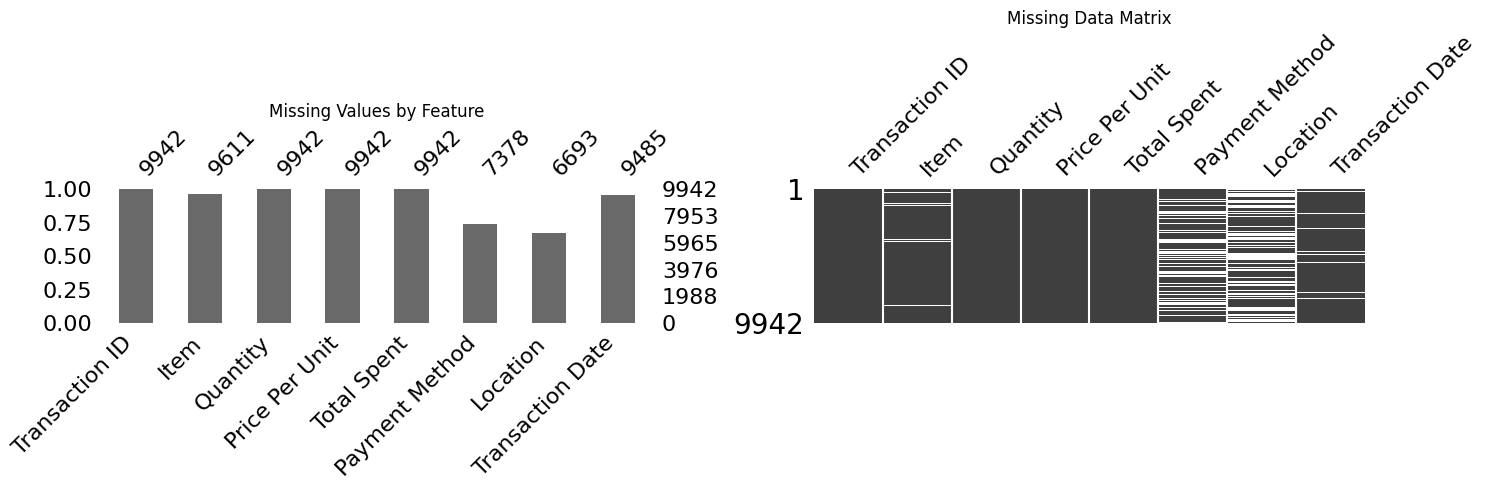

In [4]:
# 2.3 Missing data identification
# Percentage of missing values
missing_percent = (data.isnull().sum() / len(data)) * 100
missing_data = pd.DataFrame({
    'Feature': missing_percent.index,
    'Missing %': missing_percent.values
})
print("Percentage of Missing Values per Feature:")
print(missing_data)
# Checking if missing values are related
missing_patterns = data[['Payment Method', 'Location', 'Transaction Date']].isnull()
print("Correlation of missing values:")
print(missing_patterns.corr())

# Checking if missing Payment Method is related to specific items
payment_missing_by_item = data[data['Payment Method'].isnull()]['Item'].value_counts(normalize=True)
print("\nItems when Payment Method is missing:")
print(payment_missing_by_item.head(10))

# Bar chart and matrix of missing data
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

msno.bar(data, ax=axes[0])
axes[0].set_title('Missing Values by Feature')

msno.matrix(data, ax=axes[1])
axes[1].set_title('Missing Data Matrix')
plt.tight_layout()
plt.show()

In [5]:
# 2.4 Data encoding
#Handling missing catergorical values
data.replace(["error", "unknown", "Error", "Unknown",'ERROR','UNKNOWN'], np.nan, inplace=True)
# Creating pricing mapping for Item
price_to_item = (
    data.dropna(subset=["Item"])
        .groupby("Price Per Unit")["Item"]
        .agg(lambda x: x.mode()[0])
        .to_dict()
)
# Fill in the missing values using the pricing map
data.loc[
    data["Item"].isna() & data["Price Per Unit"].notna(),
    "Item"
] = data["Price Per Unit"].map(price_to_item)
# If there are still missing values we fill them with the value that appears the mos
mode_item = data["Item"].mode()[0]
data["Item"] = data["Item"].fillna(mode_item)

#Identifying variable
print("Numerical variables: ",["Quantity, Price Per Uni, Total Spent"])
print("Catergorical variables: ",["Item, Location, Payment Method"])

#Drop rows with missing Transaction Date
data_clean = data.dropna(subset=['Transaction Date']).copy()
# Now we drop the Location column due to its high missing data percantage(39%)
data_clean = data_clean.drop(columns = ["Location"])

# Drop Transaction ID column to avoid overfitting
data_clean = data_clean.drop(columns = ["Transaction ID"])

# Using frequency encoding for Items since it has many unique values
item_frequency = data_clean["Item"].value_counts()
# Mapping frequencies to the Item column
data_clean["Item"] = data_clean["Item"].map(item_frequency)

# Handling missing payment method values
data_clean["Payment Method"] = data_clean["Payment Method"].fillna("Missing")
# Create dummy variables
payment_dummies = pd.get_dummies(data_clean["Payment Method"], prefix="Payment_Method")

# Add new columns to dataset
data_encode = pd.concat([data_clean, payment_dummies], axis=1)

# Drop original column
data_encode = data_encode.drop("Payment Method", axis=1)

# View result
print(data_encode.head())


Numerical variables:  ['Quantity, Price Per Uni, Total Spent']
Catergorical variables:  ['Item, Location, Payment Method']
   Item  Quantity  Price Per Unit  Total Spent Transaction Date  \
0  1239       2.0             2.0          4.0       2023-09-08   
1  1077       4.0             3.0         12.0       2023-05-16   
2  1144       4.0             1.0          4.0       2023-07-19   
3  1212       2.0             5.0         10.0       2023-04-27   
4  1239       2.0             2.0          4.0       2023-06-11   

   Payment_Method_Cash  Payment_Method_Credit Card  \
0                False                        True   
1                 True                       False   
2                False                        True   
3                False                       False   
4                False                       False   

   Payment_Method_Digital Wallet  Payment_Method_Missing  
0                          False                   False  
1                          Fals

In [6]:
# 2.5 Imputation techniques
impute_cols = ['Quantity', 'Price Per Unit', 'Total Spent'] + \
              [col for col in data_encode.columns if col.startswith('payment_method_')]

# Median imputation
df_impute = data_encode[impute_cols].copy()
print(f"Data prepared for imputation. Shape: {df_impute.shape}")

median_imputer = SimpleImputer(strategy='median')
data_median = df_impute.copy()
numerical_cols = ['Quantity', 'Price Per Unit', 'Total Spent']
data_median[numerical_cols] = median_imputer.fit_transform(data_median[numerical_cols])

# Imputed values
print("\nMedian values used for imputation:")
for col in numerical_cols:
    median_val = df_impute[col].median()
    print(f"{col}: {median_val:.2f}")

# Mode imputation
data_mode = df_impute.copy()
payment_cols = [col for col in data_mode.columns if col.startswith('payment_method_')]

# For each payment method column, we fill missing with 0
data_mode[payment_cols] = data_mode[payment_cols].fillna(0)

print("Missing values in payment method columns filled with 0")
print("\nVerification:")
print(data_mode[payment_cols].isnull().sum())
print("In this dataset, all categorical variables have been encoded, so missing values are set to 0.")

# Regression imputation
data_reg = df_impute.copy()

# For demonstration, impute Total Spent using Quantity and Price Per Unit
# First, get rows where Total Spent is missing but predictors are present
missing_total = data_reg['Total Spent'].isnull()
has_predictors = data_reg['Quantity'].notnull() & data_reg['Price Per Unit'].notnull()
train_rows = ~missing_total & has_predictors
predict_rows = missing_total & has_predictors

if predict_rows.sum() > 0:
    # Train regression model
    X_train = data_reg.loc[train_rows, ['Quantity', 'Price Per Unit']]
    y_train = data_reg.loc[train_rows, 'Total Spent']
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Predict missing values
    X_predict = data_reg.loc[predict_rows, ['Quantity', 'Price Per Unit']]
    data_reg.loc[predict_rows, 'Total Spent'] = model.predict(X_predict)
    
    print(f"Imputed {predict_rows.sum()} missing Total Spent values using regression")
    print(f"R² score: {model.score(X_train, y_train):.3f}")
else:
    print("No rows with missing Total Spent but complete predictors")

median_imputer = SimpleImputer(strategy='median')
df_reg = pd.DataFrame(
    median_imputer.fit_transform(data_reg),
    columns=data_reg.columns
)

print("Regression-based imputation complete!")



Data prepared for imputation. Shape: (9485, 3)

Median values used for imputation:
Quantity: 3.00
Price Per Unit: 3.00
Total Spent: 8.00
Missing values in payment method columns filled with 0

Verification:
Series([], dtype: float64)
In this dataset, all categorical variables have been encoded, so missing values are set to 0.
No rows with missing Total Spent but complete predictors
Regression-based imputation complete!
